In [23]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect("photonic_benchmark.db")



In [ ]:
# Zelle 2: Daten laden + erste Übersicht
df = con.execute("""
    SELECT * FROM experiments 
    ORDER BY matrix_size, noise_level
""").df()

print(f"Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print("\nSpalten:")
print(df.columns.tolist())

display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sample_id         210 non-null    int64         
 1   matrix_size       210 non-null    int64         
 2   noise_level       210 non-null    float64       
 3   drift_factor      210 non-null    float64       
 4   crosstalk_factor  210 non-null    float64       
 5   bit_precision     210 non-null    int64         
 6   mae               210 non-null    float64       
 7   rmse              210 non-null    float64       
 8   snr_db            210 non-null    float64       
 9   effective_bits    210 non-null    float64       
 10  timestamp         210 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(7), int64(3)
memory usage: 18.2 KB
                  mae  effective_bits     snr_db
matrix_size                                     
32           0.005228    

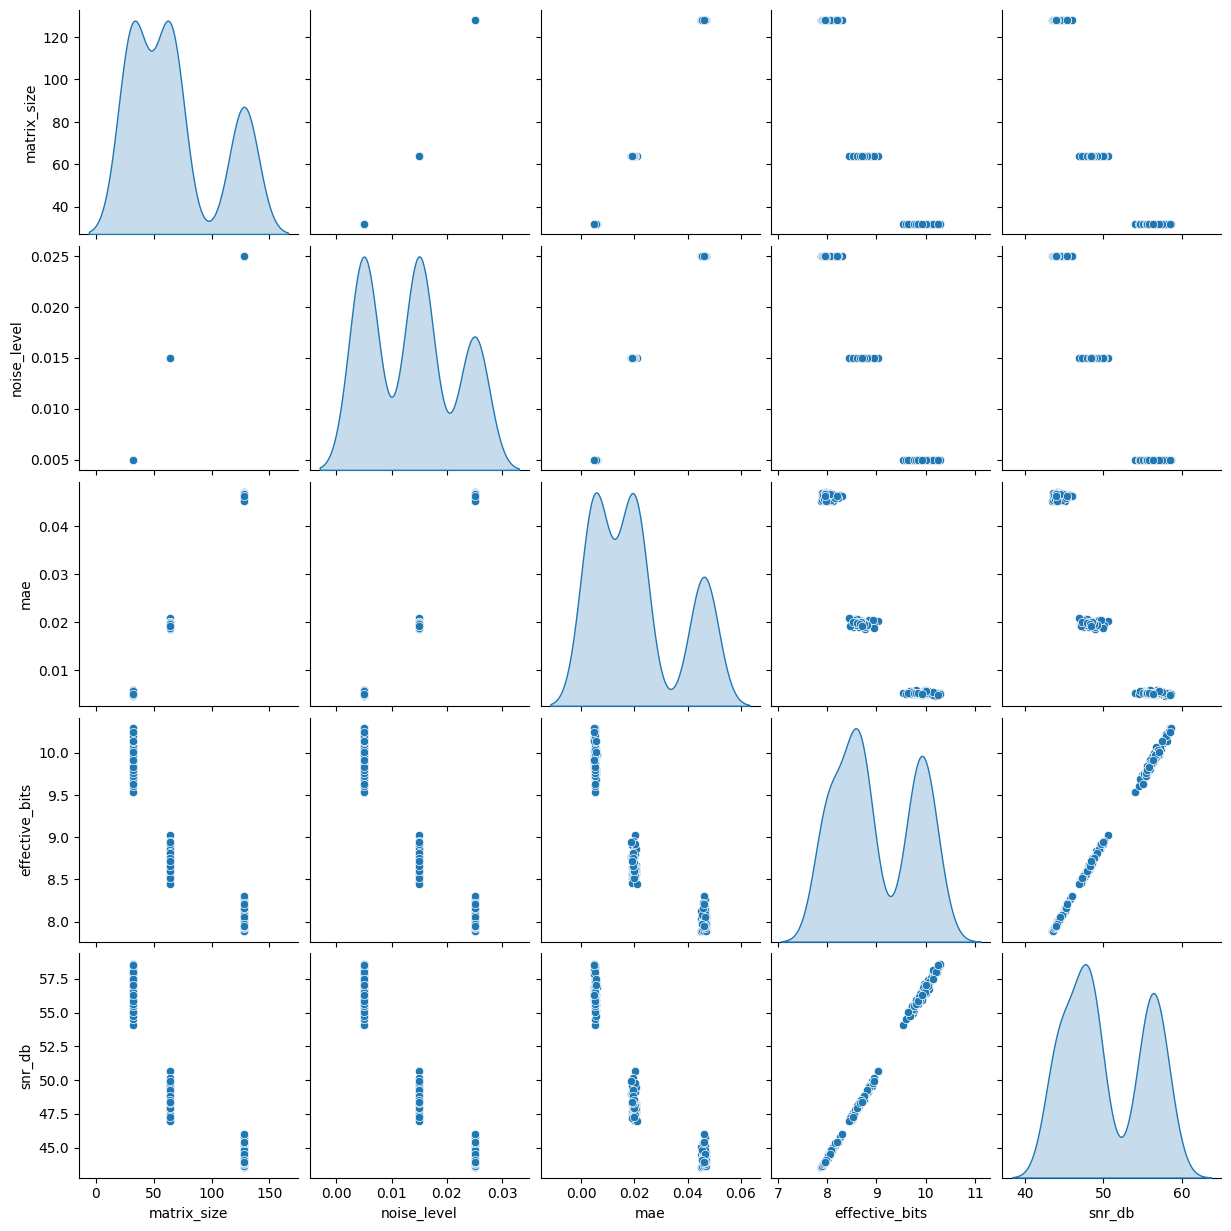

In [24]:
df.info()
#df.bit_precision.head(11)

# Übersicht
print(df.groupby('matrix_size')[['mae', 'effective_bits', 'snr_db']].mean())

# Visualisierung
sns.pairplot(df[['matrix_size', 'noise_level', 'mae', 'effective_bits', 'snr_db']], diag_kind='kde')
plt.show()

In [12]:
con.close()